In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
from matplotlib import cm

In [2]:
mithril_predictions = pd.read_csv("../checkpoints/tAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
mithril_predictions.loc[mithril_predictions.tAPOGEE_oob_score.isna(), "tAPOGEE_oob_score"] = mithril_predictions.tAPOGEE_score
mithril_predictions

,Start,Ref,Alt,Gene_symbol,gene.position,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,,,,,,
MITHRIL.1728,577,G,A,MT-TF,1,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,577,G,C,MT-TF,1,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,577,G,T,MT-TF,1,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,578,T,A,MT-TF,2,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,578,T,C,MT-TF,2,0.632326,0.632326,0.791225,VUS
...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,MT-TP,2,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,16022,T,G,MT-TP,2,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,16023,G,A,MT-TP,1,0.841406,0.834604,0.999351,pathogenic


In [3]:
gnomad_freq = pd.read_csv("../../common_data/nAPOGEE_Gnomad_het.csv", sep="\t", index_col="Mithril_id").loc[mithril_predictions.index]
gnomad_freq = (
    gnomad_freq.hl_hist.str.split("|", expand=True).fillna(0).astype(int)+\
    gnomad_freq.heteroplasmy_below_10_percent_hist.str.split("|", expand=True).fillna(0).astype(int)
)
# gnomad_freq.columns/=10
gnomad_freq

,0,1,2,3,4,5,6,7,8,9
Mithril_id,,,,,,,,,,
MITHRIL.1728,1,0,0,0,0,0,0,0,0,0
MITHRIL.1729,0,0,0,0,0,0,0,0,0,0
MITHRIL.1730,0,0,0,0,0,0,0,0,0,0
MITHRIL.1731,0,0,0,0,0,0,0,0,0,0
MITHRIL.1732,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,3,0,0,0,0,0,0,0,0,1
MITHRIL.48240,0,0,0,0,0,0,0,0,0,0
MITHRIL.48241,5,0,0,0,0,0,0,0,0,0


([], [])

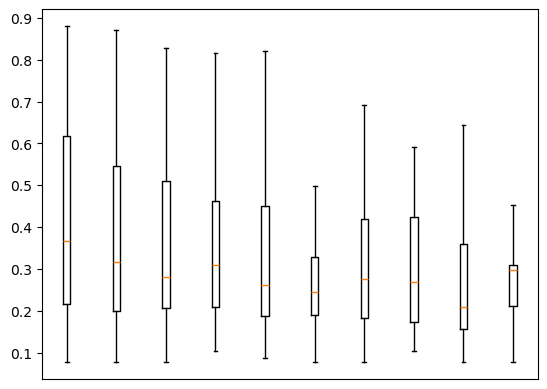

In [4]:
for het in gnomad_freq.columns:
    plt.boxplot(
        mithril_predictions.tAPOGEE_oob_score.repeat(gnomad_freq[het]),
        positions=[het],
        showfliers=False
    )
plt.xticks([])

In [5]:
bins = np.linspace(0,1,41)
bins

array([0.   , 0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  ,
       0.225, 0.25 , 0.275, 0.3  , 0.325, 0.35 , 0.375, 0.4  , 0.425,
       0.45 , 0.475, 0.5  , 0.525, 0.55 , 0.575, 0.6  , 0.625, 0.65 ,
       0.675, 0.7  , 0.725, 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875,
       0.9  , 0.925, 0.95 , 0.975, 1.   ])

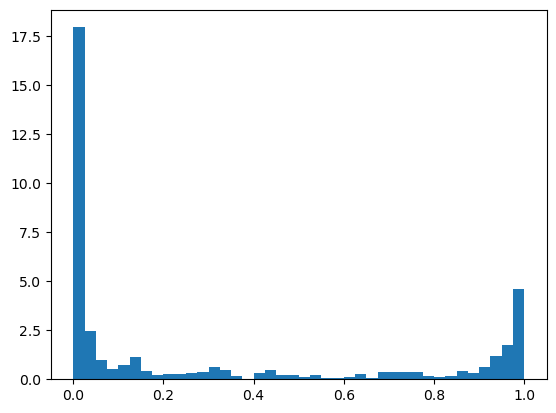

In [6]:
plt.hist(mithril_predictions.tAPOGEE_posterior.repeat(gnomad_freq[0]), bins=bins, density=True)
plt.show()

In [7]:
labels = ["B", "LB", "VUS", "LP", "P"]
proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(gnomad_freq[het]),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels]
proportions

tAPOGEE_posterior
B      0.003226
LB     0.358735
VUS    0.625703
LP     0.011506
P      0.000830
Name: proportion, dtype: float64

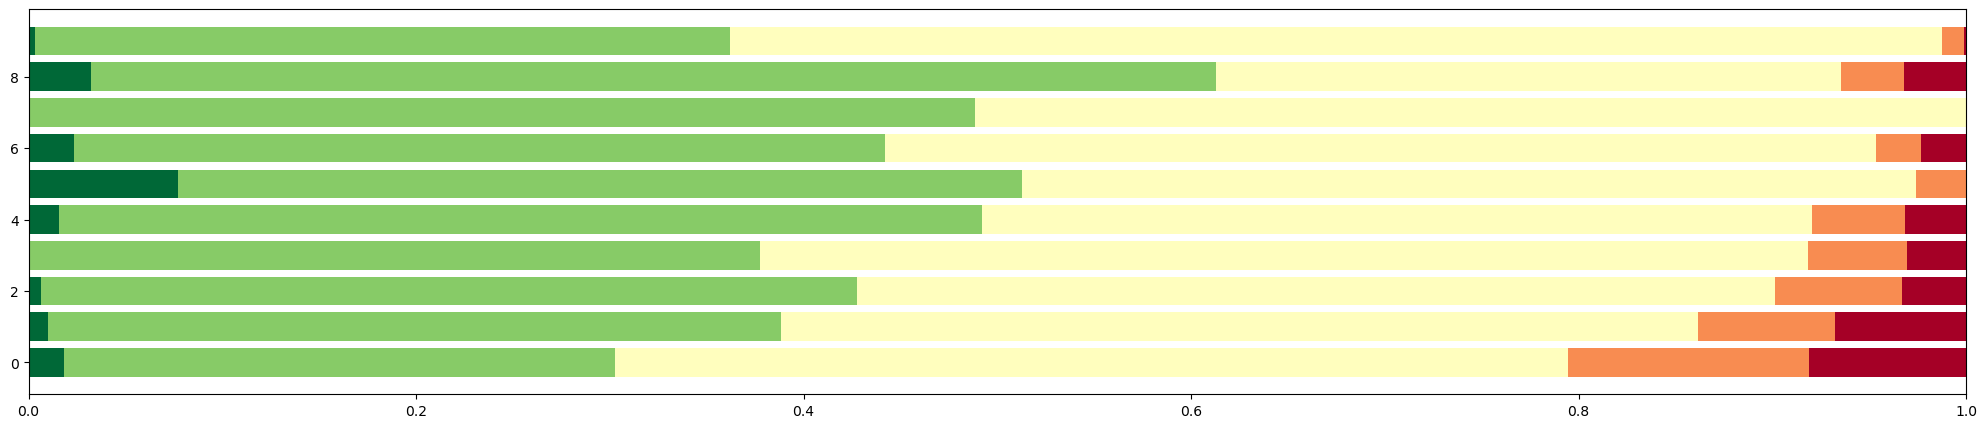

In [8]:
plt.figure(figsize=(25,5))
for het in gnomad_freq.columns:

    proportions = pd.cut(
        mithril_predictions.tAPOGEE_posterior.repeat(gnomad_freq[het]),
        bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
        labels=labels
    ).value_counts(normalize=True).loc[labels]

    plt.barh(
        y=[het], width=proportions,
        left=proportions.cumsum()-proportions,
        color=cm.RdYlGn_r(np.linspace(0,1,5))
    )

plt.show()

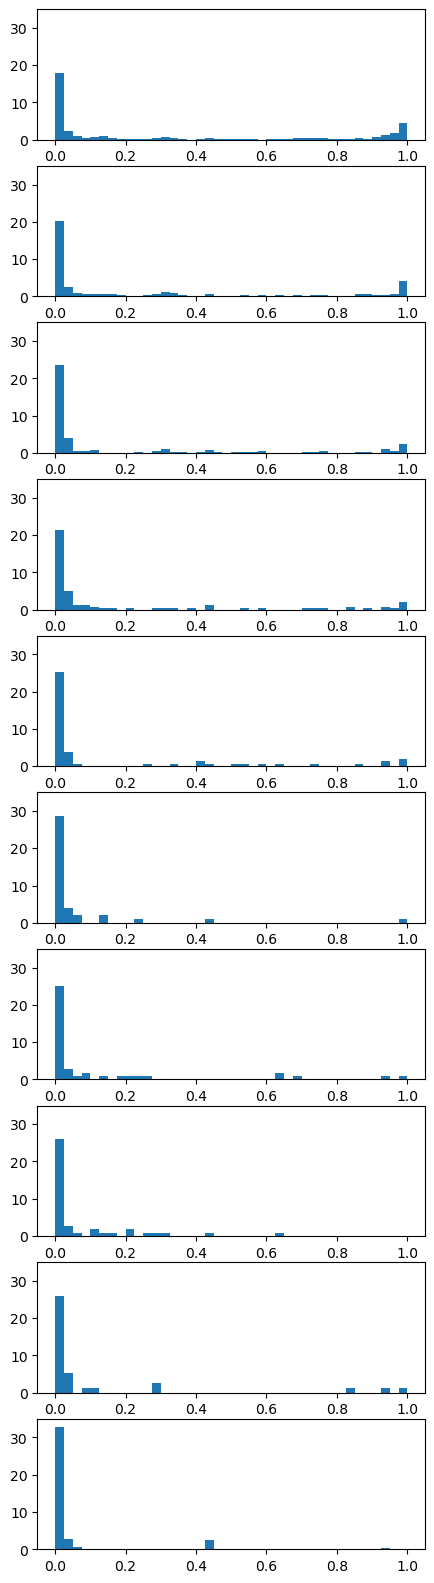

In [9]:
plt.figure(figsize=(5,20))

i = 0
for het in gnomad_freq.columns:
    i+=1
    plt.subplot(10,1,i)

    plt.hist(
        mithril_predictions.tAPOGEE_posterior.repeat(gnomad_freq[het]),
        bins=bins, density=True
    )

    plt.ylim(0, 35)

plt.show()

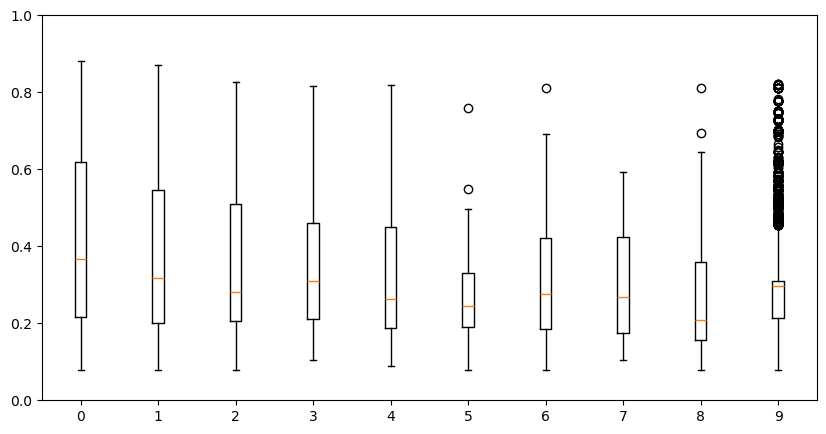

In [10]:
plt.figure(figsize=(10,5))

for het in gnomad_freq.columns:

    plt.boxplot(
        mithril_predictions.tAPOGEE_oob_score.repeat(gnomad_freq[het]),
        positions=[het]
    )

plt.ylim(0, 1)
plt.show()

In [28]:
low_het_variants = gnomad_freq.loc[:,gnomad_freq.columns<2].sum(axis=1)
mid_het_variants = gnomad_freq.loc[:,(gnomad_freq.columns>=2)&(gnomad_freq.columns<8)].sum(axis=1)
high_het_variants = gnomad_freq.loc[:,gnomad_freq.columns>=8].sum(axis=1)
low_het_variants.sum(), mid_het_variants.sum(), high_het_variants.sum()

(np.int64(4754), np.int64(438), np.int64(53045))

In [29]:
high_het_variants.sum()/gnomad_freq.values.sum()

np.float64(0.9108470559953294)

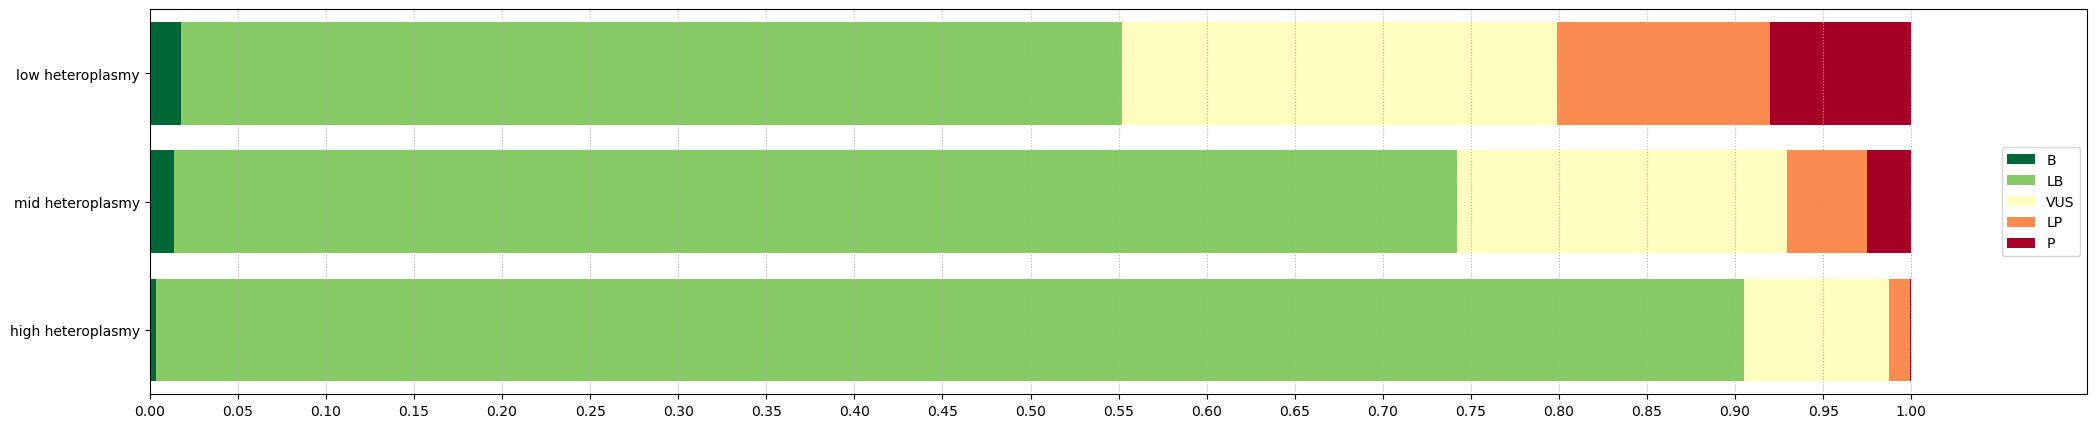

In [103]:
plt.figure(figsize=(25,5))


proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(low_het_variants),
    bins=[0, 0.001, 0.1, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels]

plt.barh(
    y=0, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)),
    label=labels
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(mid_het_variants),
    bins=[0, 0.001, 0.1, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels]

plt.barh(
    y=1, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5))
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(high_het_variants),
    bins=[0, 0.001, 0.1, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels]

plt.barh(
    y=2, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5))
)

plt.yticks(range(3), ["low heteroplasmy", "mid heteroplasmy", "high heteroplasmy"])
plt.xticks(np.linspace(0,1,21))

plt.grid(axis="x", linestyle=":")
plt.legend(loc="center right")
plt.ylim(2.5,-.5)
plt.xlim(0,1.1)

plt.savefig("../../figures/svg/tRNA_gnomad.svg", bbox_inches="tight")
plt.show()

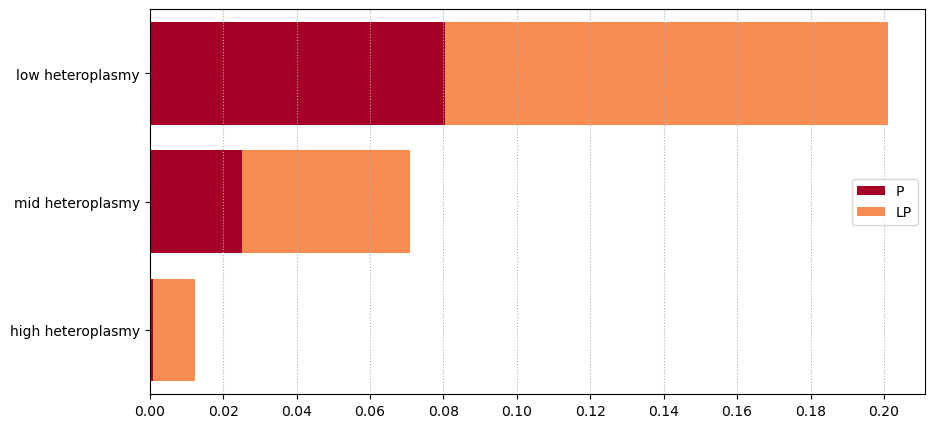

In [31]:
plt.figure(figsize=(10,5))

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(low_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.barh(
    y=0, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1]),
    label=["P", "LP"]
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(mid_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.barh(
    y=1, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1])
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(high_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.barh(
    y=2, width=proportions,
    left=proportions.cumsum()-proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1])
)

plt.yticks(range(3), ["low heteroplasmy", "mid heteroplasmy", "high heteroplasmy"])
plt.xticks(np.linspace(0,0.2,11))

plt.grid(axis="x", linestyle=":")
plt.legend(loc="center right")
plt.ylim(2.5,-.5)
plt.show()

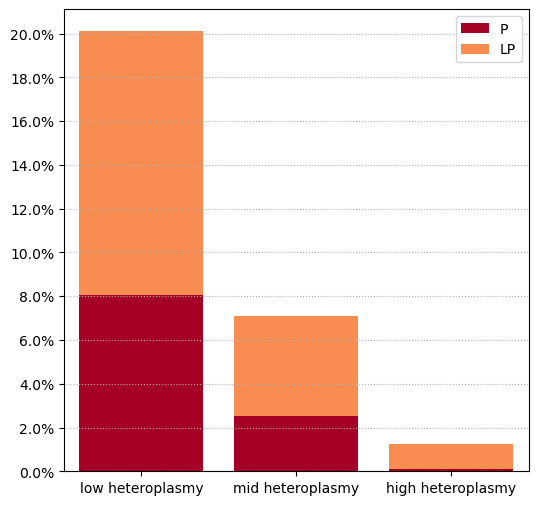

In [32]:
plt.figure(figsize=(6, 6))  # flipped figsize for vertical bars

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(low_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.bar(
    x=0, height=proportions,
    bottom=proportions.cumsum() - proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1]),
    label=["P", "LP"]
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(mid_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.bar(
    x=1, height=proportions,
    bottom=proportions.cumsum() - proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1])
)

proportions = pd.cut(
    mithril_predictions.tAPOGEE_posterior.repeat(high_het_variants),
    bins=[0, 0.001, 0.01, 0.9, 0.99, 1],
    labels=labels
).value_counts(normalize=True).loc[labels[::-1]].drop(["B", "LB", "VUS"])

plt.bar(
    x=2, height=proportions,
    bottom=proportions.cumsum() - proportions,
    color=cm.RdYlGn_r(np.linspace(0,1,5)[::-1])
)

plt.xticks(range(3), ["low heteroplasmy", "mid heteroplasmy", "high heteroplasmy"])
plt.yticks(np.linspace(0, 0.2, 11), [str(round(x*100, 1))+"%" for x in np.linspace(0, 0.2, 11)])
plt.grid(axis="y", linestyle=":")
plt.legend(loc="upper right")
plt.xlim(-0.5, 2.5)
plt.savefig("../../figures/svg/tRNA_gnomad_pathogenicity.svg", bbox_inches="tight")
plt.show()


([], [])

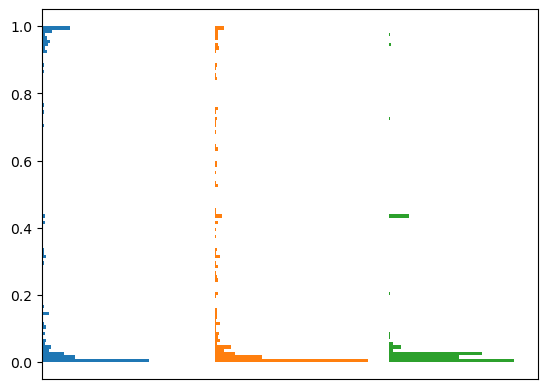

In [33]:
plt.hist(mithril_predictions.tAPOGEE_posterior.repeat(low_het_variants), bins=np.linspace(0,1,101), orientation="horizontal", density=True, bottom=0, )
plt.hist(mithril_predictions.tAPOGEE_posterior.repeat(mid_het_variants), bins=np.linspace(0,1,101), orientation="horizontal", density=True, bottom=50, )
plt.hist(mithril_predictions.tAPOGEE_posterior.repeat(high_het_variants), bins=np.linspace(0,1,101), orientation="horizontal", density=True, bottom=100, )
plt.xticks([])

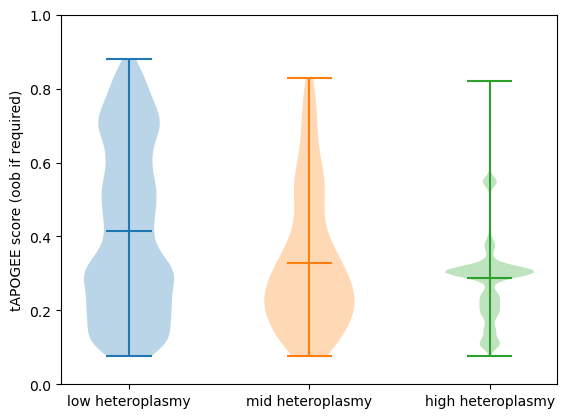

In [34]:
plt.violinplot(mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants), positions=[0], showmeans=True, showmedians=False)
plt.violinplot(mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants), positions=[1], showmeans=True, showmedians=False)
plt.violinplot(mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants), positions=[2], showmeans=True, showmedians=False)
plt.xticks([0,1,2], ["low heteroplasmy", "mid heteroplasmy", "high heteroplasmy"])
plt.ylabel("tAPOGEE score (oob if required)")
plt.ylim(0,1)
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x753e355f5090>,
 'caps': [<matplotlib.lines.Line2D at 0x753e355f6710>,
 'boxes': [<matplotlib.lines.Line2D at 0x753e355f51d0>],
 'medians': [<matplotlib.lines.Line2D at 0x753e355f6c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x753e355f6990>],
 'means': [<matplotlib.lines.Line2D at 0x753e355f6ad0>]}

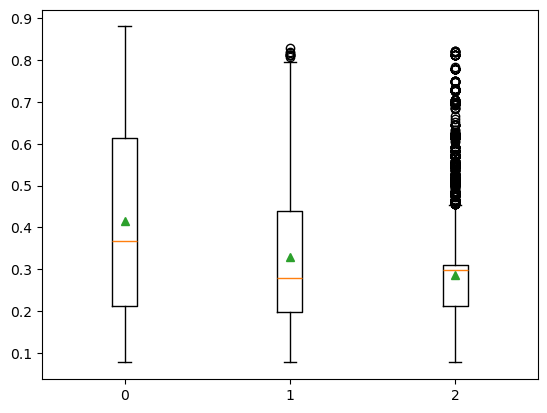

In [35]:
plt.boxplot(mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants), positions=[0], showmeans=True)
plt.boxplot(mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants), positions=[1], showmeans=True)
plt.boxplot(mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants), positions=[2], showmeans=True)

In [36]:
min_values = mithril_predictions.groupby("category").tAPOGEE_oob_score.min()
max_values  = mithril_predictions.groupby("category").tAPOGEE_oob_score.max()
min_values, max_values

(category
 VUS                  0.428930
 benign               0.066530
 likely benign        0.094913
 likely pathogenic    0.672303
 pathogenic           0.760850
 Name: tAPOGEE_oob_score, dtype: float64,
 category
 VUS                  0.671395
 benign               0.091400
 likely benign        0.428288
 likely pathogenic    0.760676
 pathogenic           0.883694
 Name: tAPOGEE_oob_score, dtype: float64)

In [37]:
low_het_proportions = mithril_predictions.category.repeat(low_het_variants)\
    .groupby(mithril_predictions.category.repeat(low_het_variants)).size()/low_het_variants.sum()
low_het_proportions

category
VUS                  0.247160
benign               0.017880
likely benign        0.533866
likely pathogenic    0.120740
pathogenic           0.080353
Name: category, dtype: float64

In [38]:
mid_het_proportions = mithril_predictions.category.repeat(mid_het_variants)\
    .groupby(mithril_predictions.category.repeat(mid_het_variants)).size()/mid_het_variants.sum()
mid_het_proportions

category
VUS                  0.187215
benign               0.013699
likely benign        0.728311
likely pathogenic    0.045662
pathogenic           0.025114
Name: category, dtype: float64

In [39]:
high_het_proportions = mithril_predictions.category.repeat(high_het_variants)\
    .groupby(mithril_predictions.category.repeat(high_het_variants)).size()/high_het_variants.sum()
high_het_proportions

category
VUS                  0.082590
benign               0.003243
likely benign        0.901800
likely pathogenic    0.011519
pathogenic           0.000848
Name: category, dtype: float64

(0.0, 3.0)

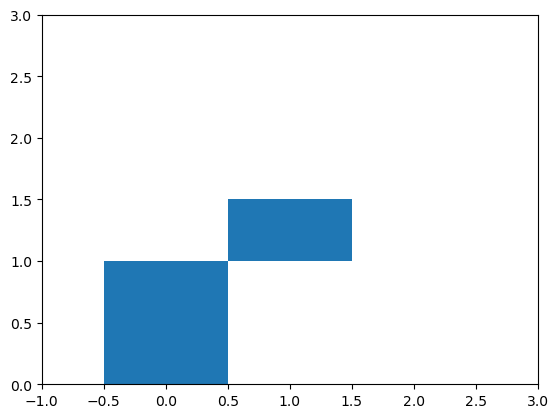

In [40]:
def plot_rectangle(bottom=0, top=0, x=0, width=1, **kwargs):
    plt.gca().add_patch(
        plt.Rectangle((x-width/2, bottom), width, top-bottom, **kwargs)
    )

plot_rectangle(0, 1, 0, 1)
plot_rectangle(1, 1.5, 1, 1)
plt.xlim(-1, 3)
plt.ylim(0,3)

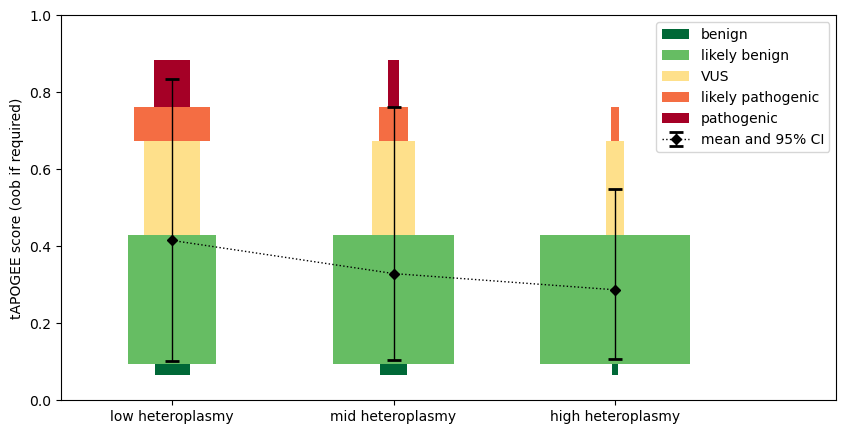

In [41]:
plt.figure(figsize=(10,5))

#### LOW HET ####


# benign
plot_rectangle(
    min_values["benign"], min_values["likely benign"],
    width=.25*low_het_proportions["benign"]/(min_values["likely benign"]-min_values["benign"]),
    x=0, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[0], lw=0,
    label="benign"
)

# likely benign
plot_rectangle(
    min_values["likely benign"], min_values["VUS"],
    width=.25*low_het_proportions["likely benign"]/(min_values["VUS"]-min_values["likely benign"]),
    x=0, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[1], lw=0,
    label="likely benign"
)

#VUS
plot_rectangle(
    min_values["VUS"], min_values["likely pathogenic"],
    width=.25*low_het_proportions["VUS"]/(min_values["likely pathogenic"]-min_values["VUS"]),
    x=0, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[3], lw=0,
    label="VUS"
)

# likely pathogenic
plot_rectangle(
    min_values["likely pathogenic"], min_values["pathogenic"],
    width=.25*low_het_proportions["likely pathogenic"]/(min_values["pathogenic"]-min_values["likely pathogenic"]),
    x=0, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[4], lw=0,
    label="likely pathogenic"
)

# likely pathogenic
plot_rectangle(
    min_values["pathogenic"], max_values["pathogenic"],
    width=.25*low_het_proportions["pathogenic"]/(max_values["pathogenic"]-min_values["pathogenic"]),
    x=0, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[5], lw=0,
    label="pathogenic"
)


#### mid HET ####

# benign
plot_rectangle(
    min_values["benign"], min_values["likely benign"],
    width=.25*mid_het_proportions["benign"]/(min_values["likely benign"]-min_values["benign"]),
    x=1, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[0], lw=0,
    # label="benign"
)

# likely benign
plot_rectangle(
    min_values["likely benign"], min_values["VUS"],
    width=.25*mid_het_proportions["likely benign"]/(min_values["VUS"]-min_values["likely benign"]),
    x=1, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[1], lw=0,
    # label="likely benign"
)

#VUS
plot_rectangle(
    min_values["VUS"], min_values["likely pathogenic"],
    width=.25*mid_het_proportions["VUS"]/(min_values["likely pathogenic"]-min_values["VUS"]),
    x=1, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[3], lw=0,
    # label="VUS"
)

# likely pathogenic
plot_rectangle(
    min_values["likely pathogenic"], min_values["pathogenic"],
    width=.25*mid_het_proportions["likely pathogenic"]/(min_values["pathogenic"]-min_values["likely pathogenic"]),
    x=1, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[4], lw=0,
    # label="likely pathogenic"
)

# likely pathogenic
plot_rectangle(
    min_values["pathogenic"], max_values["pathogenic"],
    width=.25*mid_het_proportions["pathogenic"]/(max_values["pathogenic"]-min_values["pathogenic"]),
    x=1, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[5], lw=0,
    # label="pathogenic"
)


#### high HET ####

# benign
plot_rectangle(
    min_values["benign"], min_values["likely benign"],
    width=.25*high_het_proportions["benign"]/(min_values["likely benign"]-min_values["benign"]),
    x=2, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[0], lw=0,
    # label="benign"
)

# likely benign
plot_rectangle(
    min_values["likely benign"], min_values["VUS"],
    width=.25*high_het_proportions["likely benign"]/(min_values["VUS"]-min_values["likely benign"]),
    x=2, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[1], lw=0,
    # label="likely benign"
)

#VUS
plot_rectangle(
    min_values["VUS"], min_values["likely pathogenic"],
    width=.25*high_het_proportions["VUS"]/(min_values["likely pathogenic"]-min_values["VUS"]),
    x=2, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[3], lw=0,
    # label="VUS"
)

# likely pathogenic
plot_rectangle(
    min_values["likely pathogenic"], min_values["pathogenic"],
    width=.25*high_het_proportions["likely pathogenic"]/(min_values["pathogenic"]-min_values["likely pathogenic"]),
    x=2, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[4], lw=0,
    # label="likely pathogenic"
)

# pathogenic
plot_rectangle(
    min_values["pathogenic"], max_values["pathogenic"],
    width=.25*high_het_proportions["pathogenic"]/(max_values["pathogenic"]-min_values["pathogenic"]),
    x=2, color=cm.RdYlGn_r(np.linspace(0,1,6)[::])[5], lw=0,
    # label="pathogenic"
)



plt.errorbar(
    np.arange(3),
    (
        mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).mean(),
        mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).mean(),
        mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).mean(),
    ),
    yerr=[
        np.array([
            mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).mean() - mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).quantile(0.025),
            mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).mean() - mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).quantile(0.025),
            mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).mean() - mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).quantile(0.025),
        ]),
        np.array([
            -mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).mean() + mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).quantile(0.975),
            -mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).mean() + mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).quantile(0.975),
            -mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).mean() + mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).quantile(0.975),
        ]),
    ],
    color="k", lw=1, ls=":", marker="D", ms=5, capsize=5, capthick=2, label="mean and 95% CI"

)





plt.xticks([0,1,2], ["low heteroplasmy", "mid heteroplasmy", "high heteroplasmy"])
plt.ylabel("tAPOGEE score (oob if required)")
plt.legend()
plt.xlim(-.5, 3)
plt.ylim(0,1)
plt.show()

In [42]:
mithril_predictions

,Start,Ref,Alt,Gene_symbol,gene.position,tAPOGEE_score,tAPOGEE_oob_score,tAPOGEE_posterior,category
Mithril_id,,,,,,,,,
MITHRIL.1728,577,G,A,MT-TF,1,0.780641,0.780641,0.994751,pathogenic
MITHRIL.1729,577,G,C,MT-TF,1,0.703568,0.703568,0.951709,likely pathogenic
MITHRIL.1730,577,G,T,MT-TF,1,0.767472,0.767472,0.991911,pathogenic
MITHRIL.1731,578,T,A,MT-TF,2,0.520965,0.520965,0.320783,VUS
MITHRIL.1732,578,T,C,MT-TF,2,0.632326,0.632326,0.791225,VUS
...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,16022,T,C,MT-TP,2,0.665709,0.665709,0.887440,VUS
MITHRIL.48240,16022,T,G,MT-TP,2,0.773280,0.773280,0.993295,pathogenic
MITHRIL.48241,16023,G,A,MT-TP,1,0.841406,0.834604,0.999351,pathogenic


In [43]:
stats.kendalltau(
    np.concat([
        (mithril_predictions.tAPOGEE_posterior.repeat(low_het_variants)>=.90).astype(int),
        (mithril_predictions.tAPOGEE_posterior.repeat(mid_het_variants)>=.90).astype(int),
        (mithril_predictions.tAPOGEE_posterior.repeat(high_het_variants)>=.90).astype(int)
        
    ]),
    np.concat([
        np.zeros(low_het_variants.sum()),
        np.zeros(mid_het_variants.sum())+1,
        np.zeros(high_het_variants.sum())+2,
    ])

)

SignificanceResult(statistic=np.float64(-0.3064218231135383), pvalue=np.float64(0.0))

In [63]:
high_het_napogee_bootstrap = mithril_predictions.tAPOGEE_oob_score.repeat(high_het_variants).sample(high_het_variants.sum()*100, replace=True).values.reshape(-1, 100)
high_het_napogee_bootstrap.shape

(53045, 100)

In [62]:
mid_het_napogee_bootstrap = mithril_predictions.tAPOGEE_oob_score.repeat(mid_het_variants).sample(mid_het_variants.sum()*100, replace=True).values.reshape(-1, 100)
mid_het_napogee_bootstrap.shape

(438, 100)

In [61]:
low_het_napogee_bootstrap = mithril_predictions.tAPOGEE_oob_score.repeat(low_het_variants).sample(low_het_variants.sum()*100, replace=True).values.reshape(-1, 100)
low_het_napogee_bootstrap.shape

(4754, 100)

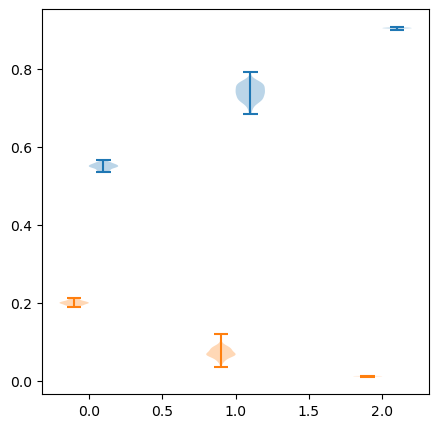

In [99]:
plt.figure(figsize=(5,5))

plt.violinplot(
    [
        (low_het_napogee_bootstrap<min_values.VUS).mean(axis=0),
        (mid_het_napogee_bootstrap<min_values.VUS).mean(axis=0),
        (high_het_napogee_bootstrap<min_values.VUS).mean(axis=0)
    ],
    positions=[0+.1, 1+.1, 2+.1],
    widths=.2
)

plt.violinplot(
    [
        (low_het_napogee_bootstrap>max_values.VUS).mean(axis=0),
        (mid_het_napogee_bootstrap>max_values.VUS).mean(axis=0),
        (high_het_napogee_bootstrap>max_values.VUS).mean(axis=0)
    ],
    positions=[0-.1, 1-.1, 2-.1],
    widths=.2
)
plt.show()